# 1. Hello QuGrid

**Reading time: about 15 minutes. Quantum computing knowledge needed: none.**

This notebook takes a power system decision problem you already understand —
where to split a network into two islands — and shows the complete path from a
MATPOWER case file to a quantum algorithm. Every quantum term is defined the
first time it appears, in power system vocabulary.

What you need to know before starting:

* A MATPOWER case is a set of arrays: `bus`, `gen`, `branch`, `gencost`.
* Line reactance `x` measures electrical distance. Its inverse `1/x` measures
  electrical coupling: a low-reactance line ties two buses together strongly.

What you do **not** need to know: qubits, gates, Hamiltonians, or any physics.

By the end you will be able to state what a quantum optimizer receives, what it
returns, and which part of the pipeline is quantum.

In [1]:
# Everything this notebook uses. QuGrid needs only NumPy, SciPy, matplotlib, and pandas.
import matplotlib.pyplot as plt
import numpy as np

import qugrid as qg

qg.viz.use_style()  # one visual system for every figure in the library
np.set_printoptions(precision=3, suppress=True)
print("QuGrid version:", qg.__version__)

QuGrid version: 0.1.0


## 1.1 The network

`qg.cases` ships the standard IEEE and PJM test systems as unmodified MATPOWER
data files. No MATLAB, no download step. We use the WSCC 9-bus system: three
generators, three loads, nine branches.

In [2]:
net = qg.cases.case9()
print(net)
print("bus numbers        ", net.bus[:, 0].astype(int))
print("load per bus [MW]  ", net.load_p)
print("generation per bus ", net.gen_p_per_bus())
print("net injection [MW] ", net.gen_p_per_bus() - net.load_p)

Network('case9': 9 buses, 9 branches, 3 generators, load 315.0 MW)
bus numbers         [1 2 3 4 5 6 7 8 9]
load per bus [MW]   [  0.   0.   0.   0.  90.   0. 100.   0. 125.]
generation per bus  [ 72.3 163.   85.    0.    0.    0.    0.    0.    0. ]
net injection [MW]  [  72.3  163.    85.     0.   -90.     0.  -100.     0.  -125. ]


`Network` is a thin wrapper over the MATPOWER arrays. `net.bus`, `net.gen`, and
`net.branch` are the raw matrices in MATPOWER column order, so anything you know
how to read in MATPOWER you can read here. Notebook 2 covers the column
constants and how to load your own `.m` file.

The `edges()` method returns the branch list as `(from_bus, to_bus, 1/x)` using
internal 0-based bus positions. The weight `1/x` is the electrical coupling
strength between the two buses.

In [3]:
for f, t, w in net.edges():
    print(f"bus {int(net.bus[f, 0])} -- bus {int(net.bus[t, 0])}   coupling 1/x = {w:6.2f}")

bus 1 -- bus 4   coupling 1/x =  17.36
bus 4 -- bus 5   coupling 1/x =  10.87
bus 5 -- bus 6   coupling 1/x =   5.88
bus 3 -- bus 6   coupling 1/x =  17.06
bus 6 -- bus 7   coupling 1/x =   9.92
bus 7 -- bus 8   coupling 1/x =  13.89
bus 8 -- bus 2   coupling 1/x =  16.00
bus 8 -- bus 9   coupling 1/x =   6.21
bus 9 -- bus 4   coupling 1/x =  11.76


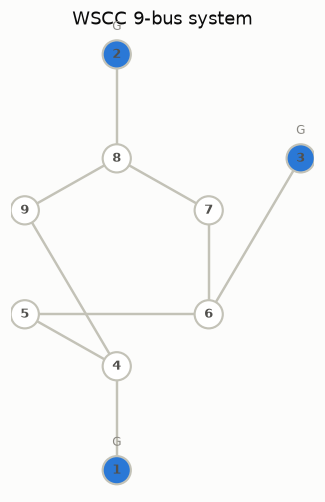

In [4]:
qg.viz.plot_network(net, title="WSCC 9-bus system")
plt.show()

The figure is a one-line diagram: filled buses carry generators (marked G), open
buses are load or transfer buses, and each line is a branch.

## 1.2 The decision problem: controlled islanding

A cascading disturbance is spreading. The operator decides to split the system
into two islands, deliberately, before the disturbance splits it uncontrolled.
A good split satisfies three conditions:

1. **Cut few and weak lines.** Opening a strongly coupled line is disruptive.
   The cost of a split is the total `1/x` of every line that crosses between the
   two islands.
2. **Balance each island.** An island whose generation and load differ by a
   large amount collapses in frequency. The imbalance is squared, so a 20 MW
   error is four times worse than a 10 MW error.
3. **Produce two islands of comparable size.** Otherwise the answer “do not
   split at all” always wins, which is not a split.

These three terms are what `qg.problems.Islanding` encodes.

## 1.3 What a QUBO is

QUBO stands for quadratic unconstrained binary optimization. It is the common
input format of today's quantum optimizers — QAOA on gate-model machines and
quantum annealers alike. A QUBO is exactly this:

* **Binary variables.** Here, one per bus: `x_i = 0` puts bus `i` in island A,
  `x_i = 1` puts it in island B. Nine buses means nine variables.
* **A quadratic objective.** A square matrix `Q` gives a number to every
  assignment through the expression `x^T Q x + offset`. Terms on the diagonal
  `Q_ii` price one bus at a time; off-diagonal terms `Q_ij` price a pair of
  buses together — which is exactly what a branch between bus `i` and bus `j`
  needs.
* **Minimize.** The answer is the assignment `x` with the lowest value.
* **Unconstrained.** There is no separate constraint list. Every requirement is
  folded into `Q` as a penalty term that adds cost when the requirement is
  broken. Notebook 2 shows how to build those penalties and how to weight them.

That is the whole format. A power system problem becomes a QUBO by choosing what
each binary variable means and writing the objective as a quadratic function of
those variables.

In [5]:
problem = qg.problems.Islanding(net)
print(problem)
print("variables            ", problem.qubo.names)
print("Q matrix shape       ", problem.qubo.q.shape)
print("constant offset      ", round(problem.qubo.offset, 4))
print("possible assignments ", 2**problem.qubo.n)

Islanding(n=9 binary variables)
variables             ['bus1', 'bus2', 'bus3', 'bus4', 'bus5', 'bus6', 'bus7', 'bus8', 'bus9']
Q matrix shape        (9, 9)
constant offset       49.131
possible assignments  512


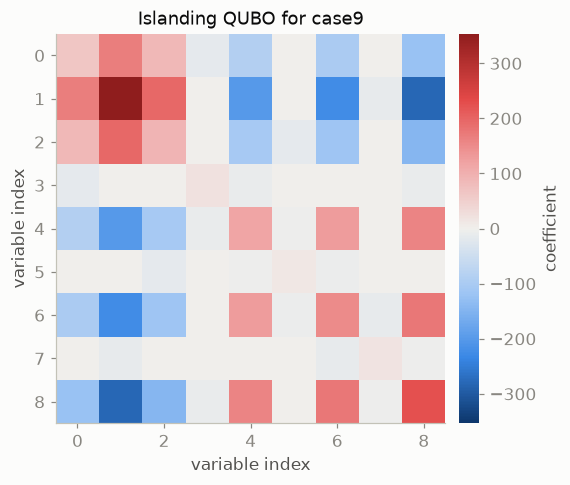

In [6]:
qg.viz.plot_qubo(problem.qubo, title="Islanding QUBO for case9")
plt.show()

Blue and red mark coefficients of opposite sign; the sparse off-diagonal
structure reproduces the branch list, because only buses joined by a branch
appear together in a quadratic term.

## 1.4 Reading the objective by hand

Before any solver runs, evaluate the objective yourself on three assignments.
`problem.qubo.energy(x)` returns the objective value and `problem.decode(x)`
translates the bitstring into engineering quantities.

In [7]:
candidates = {
    "no split (every bus in island A)": np.zeros(9, dtype=int),
    "split by bus number (1-3 | 4-9)": np.array([0, 0, 0, 1, 1, 1, 1, 1, 1]),
}
for label, x in candidates.items():
    d = problem.decode(x)
    print(f"{label}")
    print(f"   objective        {problem.qubo.energy(x):10.2f}")
    print(f"   lines cut        {d['n_cut']}")
    print(f"   island power MW  {tuple(round(p, 1) for p in d['island_power_mw'])}")
    print(f"   both connected   {d['islands_connected']}")
    print(f"   feasible         {problem.is_feasible(x)}")

no split (every bus in island A)
   objective             49.13
   lines cut        0
   island power MW  (5.3, 0.0)
   both connected   (True, False)
   feasible         False
split by bus number (1-3 | 4-9)
   objective           1457.28
   lines cut        3
   island power MW  (320.3, -315.0)
   both connected   (False, True)
   feasible         True


The no-split assignment scores 49.13. It is marked infeasible because it puts
every bus on one side, so it is not a split at all. The bus-number split scores
1457.28: it cuts three lines and leaves one island with a 320 MW surplus against
the other island’s 315 MW deficit. The squared imbalance term dominates, which
is the intended behaviour — an unbalanced island is the expensive failure.

## 1.5 Solving

`qg.solve(problem, solver=...)` runs any solver on any QuGrid problem. Start
with the two classical ones, so there is ground truth to compare against.

In [8]:
exact = qg.solve(problem, solver="exact")
print(exact.summary())

QuGrid result | solver=exact | Islanding(n=9)
  objective          27.0512
  feasible           yes
  gap vs reference   0%
  sizes              (6, 3)
  n_cut              2
  cut_weight         20.7902
  island_power_mw    (10.3, -5.0)
  islands_connected  (True, True)
  resources          wall_time_s=0.0006, states_enumerated=512


`exact` enumerates all 512 assignments, so its answer is the true minimum by
construction. This is possible here only because the problem is small; the count
doubles with every bus added.

`sa` is simulated annealing, the standard classical heuristic for QUBOs. It is
the baseline any quantum result has to beat.

In [9]:
annealed = qg.solve(problem, solver="sa", seed=0)
print(annealed.summary())

QuGrid result | solver=sa | Islanding(n=9)
  objective          27.0512
  feasible           yes
  gap vs reference   0%
  sizes              (6, 3)
  n_cut              2
  cut_weight         20.7902
  island_power_mw    (10.3, -5.0)
  islands_connected  (True, True)
  resources          wall_time_s=0.0657, n_vars=9, sweeps=1500, restarts=8, seed=0


Now the quantum solver. QAOA stands for Quantum Approximate Optimization
Algorithm. QuGrid simulates it exactly on your laptop with NumPy, so you get the
complete output distribution rather than a finite sample. `p` is the circuit
depth; notebook 3 explains what the algorithm actually does with it.

In [10]:
quantum = qg.solve(problem, solver="qaoa", p=2, seed=0)
print(quantum.summary())

QuGrid result | solver=qaoa | Islanding(n=9)
  objective          27.0512
  feasible           yes
  gap vs reference   0%
  P(optimum)         0.010
  sizes              (6, 3)
  n_cut              2
  cut_weight         20.7902
  island_power_mw    (10.3, -5.0)
  islands_connected  (True, True)
  resources          wall_time_s=0.3652, n_qubits=9, p=2, evaluations=1200, restarts=3, seed=0, expectation=119.71652


All three solvers return objective 27.05 — the same split. Read that as a
statement about the instance, not about quantum computing: nine variables is a
problem size where enumeration takes 0.1 milliseconds. Notebook 3 measures how
QAOA behaves as depth increases and states plainly where the research value is.

## 1.6 The Result object

Every solver returns the same `Result` type. These are the fields you will use.

In [11]:
print("solver             ", quantum.solver)
print("x (raw bitstring)  ", quantum.x)
print("objective          ", round(quantum.objective, 4))
print("feasible           ", quantum.feasible)
print("gap()              ", quantum.gap())
print("success_probability", round(quantum.success_probability(), 4))
print("resources          ", quantum.resources)

solver              qaoa
x (raw bitstring)   [0 0 1 0 1 1 0 0 0]
objective           27.0512
feasible            True
gap()               -1.0506644321491318e-15
success_probability 0.0095
resources           {'wall_time_s': 0.3652, 'n_qubits': 9, 'p': 2, 'evaluations': 1200, 'restarts': 3, 'seed': 0, 'expectation': 119.71652}


* **`x`** is the raw assignment, one bit per variable.
* **`objective`** is the QUBO value of `x`, in whatever units the formulation
  uses. It is not automatically an engineering quantity.
* **`decoded`** is the engineering answer: which buses form which island, which
  lines are cut, how much power each island holds. This is the field you report.
* **`feasible`** checks the original constraints, before any penalty was folded
  in. A solver can return a low objective on an infeasible point when a penalty
  weight is set too low, so always read this.
* **`gap()`** is the relative difference against the classical reference. Zero
  means the solver found the true optimum. QuGrid computes the reference
  automatically for problems with 24 variables or fewer.
* **`success_probability()`** applies to quantum solvers: the total probability
  the final quantum state assigns to optimal assignments. A quantum optimizer
  returns a probability distribution over answers, not one answer, so this
  number tells you how often an ideal, noise-free machine would hand you the
  optimum; real hardware faces less. Here it
  is about 1 percent, against 0.39 percent for uniform random guessing over 512
  states.
* **`resources`** records the cost: qubit count, circuit depth, number of
  objective evaluations, wall time, and the seed.

In [12]:
best = quantum.decoded
print("island of each bus  ", best["islands"])
print("island sizes        ", best["sizes"])
print("lines cut (internal)", best["cut_lines"])
print("cut weight          ", round(best["cut_weight"], 3))
print("island power [MW]   ", tuple(round(p, 2) for p in best["island_power_mw"]))
print("each island connected", best["islands_connected"])

island of each bus   [0 0 1 0 1 1 0 0 0]
island sizes         (6, 3)
lines cut (internal) [(3, 4), (5, 6)]
cut weight           20.79
island power [MW]    (10.3, -5.0)
each island connected (True, True)


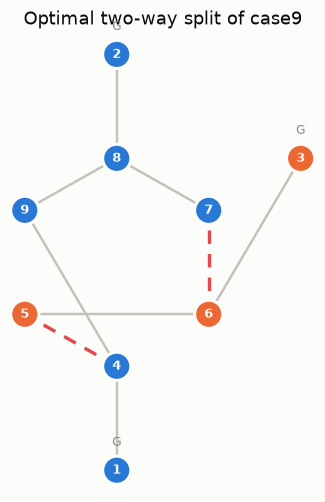

In [13]:
qg.viz.plot_network(
    net,
    islands=best["islands"],
    cut_edges=best["cut_lines"],
    title="Optimal two-way split of case9",
)
plt.show()

The colours mark the two islands and the dashed lines are the branches that get
opened. The split cuts branch 4-5 and branch 6-7, isolating buses 3, 5, and 6 as
one island: generator 3 stays with the load at bus 5 and the transfer bus 6.
Island A ends with a 10.3 MW surplus and island B with a 5.0 MW deficit, out of
315 MW of total load.

## 1.7 The three-layer mental model

Every QuGrid workflow has the same three layers, and they are independent:

| Layer | What lives there | Example in this notebook |
| --- | --- | --- |
| 1. Power problem | Engineering units, constraints, test cases | `qg.cases.case9()` |
| 2. Encoding | The mathematical form a solver accepts | `qg.problems.Islanding(net).qubo` |
| 3. Solver | Classical or quantum algorithm | `qg.solve(..., solver="qaoa")` |

Layer 2 is where the research decisions live. A quantum computer never sees a
bus or a megawatt: it sees `Q`. If the encoding is wrong, or the penalty weights
are wrong, then no solver — classical or quantum — can recover the engineering
answer you wanted. Notebook 2 is entirely about layer 2.

The layers being independent is what makes comparison honest. The same `Q` goes
to `exact`, `sa`, `qaoa`, and to real hardware, so any difference in the answer
comes from the solver and nothing else.

## 1.8 Where hardware plugs in

`qugrid.adapters` exports the same encoding to the ecosystems that talk to real
machines — `to_qiskit_operator` and `to_qiskit_qaoa` for IBM Qiskit, `to_bqm`
for D-Wave Ocean, `to_pennylane_hamiltonian` for PennyLane — so moving from the
built-in simulator to hardware changes the solver call and nothing above it.

## 1.9 Where to go next

* **Notebook 2** — load your own MATPOWER file, read the case arrays by column
  name, and build a QUBO by hand with correct penalty weights.
* **Notebook 3** — what QAOA does, with the cost landscape drawn out.
* **Notebook 4** — DC power flow as a linear system, solved with HHL and VQLS.
* **Notebook 5** — N-1 security screening with quantum kernels.